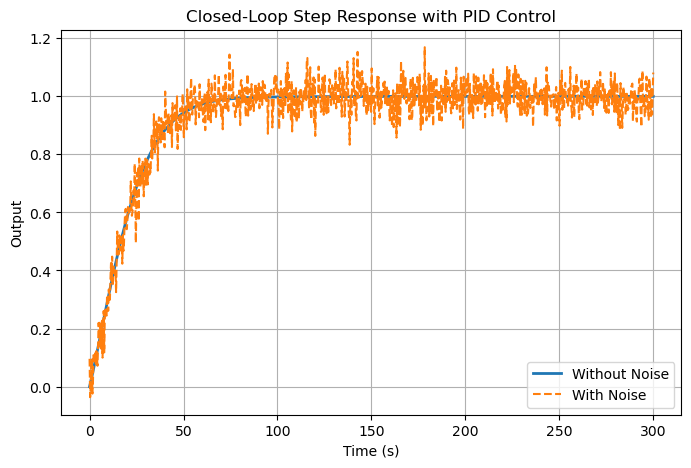

Performance Metrics:
RiseTime: 37.715259188371334
SettlingTime: 63.95196123245575
SettlingMin: 0.9027475983558658
SettlingMax: 1.0
Overshoot: 0.0
Undershoot: 0.0
Peak: 0.9997653709845117
PeakTime: 162.3395938977723
SteadyStateValue: 1.0


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import control as ctrl

# System parameters
tau1 = 10
tau2 = 20

s = ctrl.TransferFunction.s

# Plant
G = 1/((tau1*s + 1)*(tau2*s + 1))

# PID parameters
Kp = 1.3
Ki = 0.049
Kd = 5.5

C = Kp + Ki/s + Kd*s

# Closed loop system
T = ctrl.feedback(C*G, 1)

# Time vector
t = np.linspace(0, 300, 1000)

# Step response
t, y = ctrl.step_response(T, t)

# Noise
noise = 0.05*np.random.randn(len(t))
y_noisy = y + noise

# Plot
plt.figure(figsize=(8,5))
plt.plot(t, y, linewidth=2, label="Without Noise")
plt.plot(t, y_noisy, '--', label="With Noise")
plt.xlabel("Time (s)")
plt.ylabel("Output")
plt.title("Closed-Loop Step Response with PID Control")
plt.legend()
plt.grid()

plt.savefig("response.png", dpi=300)
plt.show()

# Performance
info = ctrl.step_info(T)

print("Performance Metrics:")
for key, value in info.items():
    print(f"{key}: {value}")